In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.models import LinearRegression
from src.metrics import ECM	

In [60]:
dev_original = pd.read_csv("../data/casas_dev.csv")

1.1

Fragmento random del dataset

In [61]:
dev_original.sample(10)

,precio,tipo,Área,metros_cubiertos,unidades,ambientes,pisos,pileta,lat,lon,edad
510,427.1396,casa,217.3443,130.9867,m2,9,3.0000,False,-34.8305,-58.3081,2.3911
681,0.0000,casa,229.1653,101.1217,m2,8,3.0000,True,-34.6975,-58.2637,52.9505
471,65746.9835,casa,217.5923,94.2546,m2,9,3.0000,False,-34.7743,-58.2244,45.0126
1027,22769.8016,casa,233.8455,109.2622,m2,10,3.0000,True,-34.7511,-58.2708,27.3664
314,299319.2200,depto,684.7499,671.6725,sqft,10,NaN,False,40.8079,-74.0075,4.8999
1101,223018.8922,depto,852.5713,816.7523,sqft,7,NaN,False,40.7079,-73.9655,NaN
892,139937.1005,depto,705.0746,672.7818,sqft,6,NaN,False,40.7196,-73.9326,13.1846
516,55952.4153,casa,246.2062,121.1133,m2,6,2.0000,True,-34.8053,-58.2296,66.1279
227,8213.0168,depto,67.9865,67.2738,m2,7,NaN,False,-34.7842,-58.2025,14.4935
919,280941.4816,ph,1091.5962,927.3817,sqft,9,1.0000,False,40.7605,-74.0254,48.5948


Variables posibles dentro de unidades y tipo

In [62]:
print(dev_original['tipo'].unique())
print(dev_original['unidades'].unique())


['depto' 'casa' 'ph']
['sqft' 'm2']


Lo uso porque de esta manera me aseguro que no haya otros valores posibles para luego categorizar / hacer one hot encodding en el caso del tipo.

Analisis a simple vista:
- Columna unidades: deberia estar en una misma medida, elijo m2. Esto es para que sean comparables las medidas.
- Columna pisos: demasiados NaN
- Columna pileta: convertir en 1(True) y 0(False). Elijo tener todo numericamente
- Columna tipo: pasar de variable categorica a numero
- Normalizar las variables (las escalas son demasiado distintas)

Busco NaNs en cada columna:

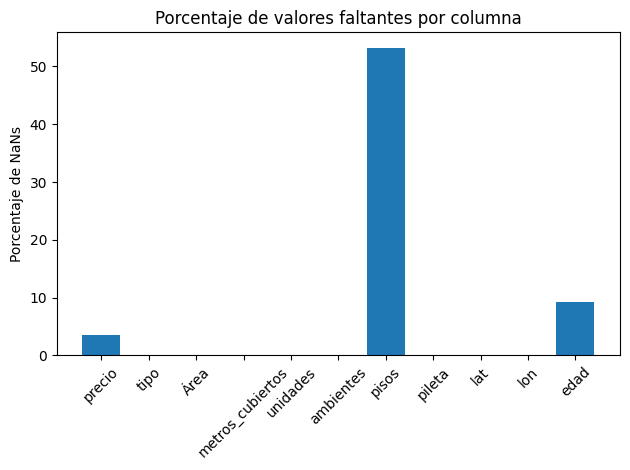

In [63]:
columnas = []
porcentajes = []
for col in dev_original.columns:
	columna = dev_original[col]
	total_NaNs_en_columna = columna.isna().sum() #sumo cantidad de NaNs 
	porcentaje_NaNs_en_columna = (total_NaNs_en_columna/dev_original.shape[0]) * 100

	columnas.append(col)
	porcentajes.append(porcentaje_NaNs_en_columna)

plt.figure()
plt.bar(columnas, porcentajes)
plt.xticks(rotation=45)
plt.ylabel("Porcentaje de NaNs")
plt.title("Porcentaje de valores faltantes por columna")
plt.tight_layout()
plt.show()


- Para los NaNs de edad usare la media de esa feature para reemplazarlos.
- Para los de precio hare lo mismo.
- En ambos casos calculare la media contemplando su ubicacion, para que la estimacion de esos valores sea lo mas adecuada posible. (esto lo hare mas adelante porque primero debo separar en train y validation para no generar data l)

- Decido eliminar la columna de pisos porque hay mas de un 50% de valores faltantes, lo que puede producir sesgos importantes. 

- Las demas no tienen  porcentajes tan significativos 
	--> utilizo media para estimar valores numericos y reemplazarlos.


Antes de eliminar veo la correlacion de precios con pisos (en los valores que no son NaN), para tomar desicion final

In [64]:
correlacion_pisos_precios = dev_original['precio'].corr(dev_original['pisos'])
print(correlacion_pisos_precios)

-0.2330073130026114


Efectivamente es conveniente eliminar la columna de pisos. Ademas de los valores faltantes, la correlacion entre precios y pisos (con los valores que si existe) es muy debil.

In [65]:
dev = dev_original.drop('pisos', axis=1) #elimina columna pisos

Todos los cambios desde ahora en dev los hare sobre una copia para luego usar el dev_original

Identifico como estan distribuidas las casas en lat y long

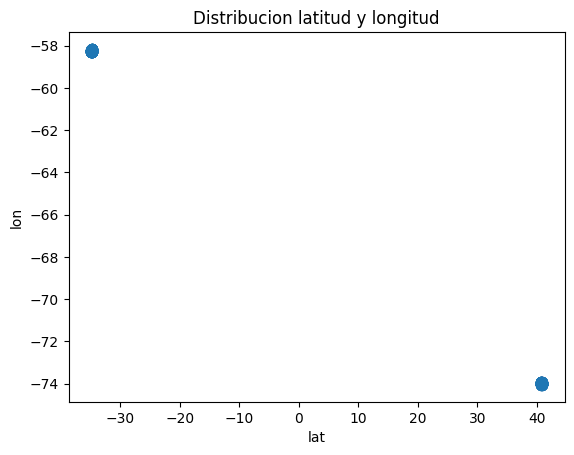

In [66]:
plt.figure()

lat = dev['lat']
lon = dev['lon']
plt.scatter(lat,lon,s=50, alpha=0.3)
plt.xlabel("lat")
plt.ylabel("lon")
plt.title("Distribucion latitud y longitud")

plt.show()

Se puede ver que la ubicacion de las casas (en lat y lon) estan concentradas unicamente en dos lugares:
Mirando el grafico se puede ver que estas son: 1 --> (-34, -58): buscandolo en el mapa equivale a la provincia de Buenos Aires (Argentina) y 2 --> (40,-74): buscandolo en el mapa equivale a New York (USA)

Agrego Feature nueva Ubicacion que reemplaza lat y long. 
Los valores seran 1 si la ubicacion es New York y 0 si es Buenos Aires (para no usar variables categoricas)

In [67]:
dev['Ubicacion'] = (dev['lat'] > 0).astype(int) #crea una columna nueva fijandose por la latitud si es New York o Argentina (solo hace falta ver latitud)

Elimino lat y long porque ubicacion las reemplazo

In [68]:
dev = dev.drop('lat',axis=1)
dev = dev.drop('lon',axis=1)

Cambio columna pileta a 1/0 en vez de True/False

In [69]:
dev['pileta'] = (dev['pileta']).astype(int)

- Convierto sqft en m2.
- Cuando la variable en Area/metros cubiertos este escrita en sqft, la paso a metros

In [70]:
dev.loc[dev['Ubicacion'] == 1, 'Área'] = dev.loc[dev['Ubicacion'] == 1, 'Área'] / 10.764 
dev.loc[dev['Ubicacion'] == 1, 'metros_cubiertos'] = dev.loc[dev['Ubicacion'] == 1, 'metros_cubiertos'] / 10.764 

Ahora elimino la columna unidades porque ya esta unificado en m2

In [71]:
dev = dev.drop('unidades',axis=1)

Tengo que cambiar tipo a variables numericas porque es categorica:
Uso One-Hot Encodding

In [72]:
dev['es_casa'] = (dev['tipo'] == 'casa').astype(int)
dev['es_ph'] = (dev['tipo'] == 'ph').astype(int)

Si no es casa ni ph, es dept

Elimino tipo porque no me sirve

In [73]:
dev = dev.drop('tipo', axis=1)

Analizo rango de precios en Argentina

In [74]:
print(dev.loc[dev['Ubicacion'] == 0, 'precio'].describe())

count      876.0000
mean     23021.1855
std      20631.9820
min          0.0000
25%       4130.0074
50%      20865.8683
75%      35116.0675
max     114468.6720
Name: precio, dtype: float64


Analizo rango de precios en USA

In [75]:
print(dev.loc[dev['Ubicacion'] == 1, 'precio'].describe())

count      669.0000
mean    185425.1816
std      77552.5505
min          0.0000
25%     139937.5556
50%     179347.2537
75%     219477.1460
max     769962.6736
Name: precio, dtype: float64


Tomo en cuenta que hay algo raro en los precios de Argentina

CHECK DE CAMBIOS EN EL DATASET

In [76]:
dev.sample(5)

,precio,Área,metros_cubiertos,ambientes,pileta,edad,Ubicacion,es_casa,es_ph
22,104369.2960,70.5124,70.3631,6,0,14.3407,1,0,0
256,129244.7117,66.2529,63.7727,6,0,10.4180,1,0,0
455,87903.0554,241.2259,133.0320,10,1,17.7139,0,1,0
1394,157844.7973,67.0164,64.4851,7,0,11.2706,1,0,0
485,180619.2279,73.5955,70.5870,7,0,2.2494,1,0,0


1.2

Analisis con Boxplot

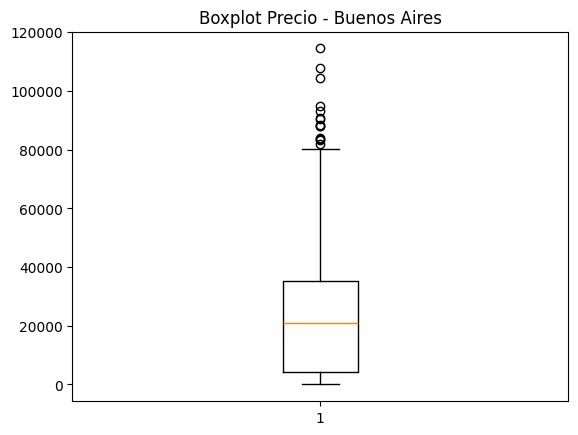

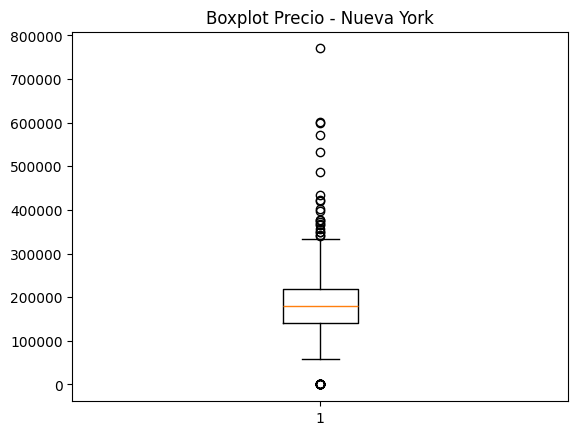

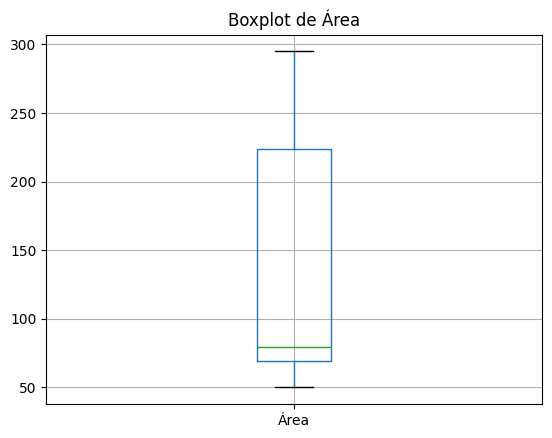

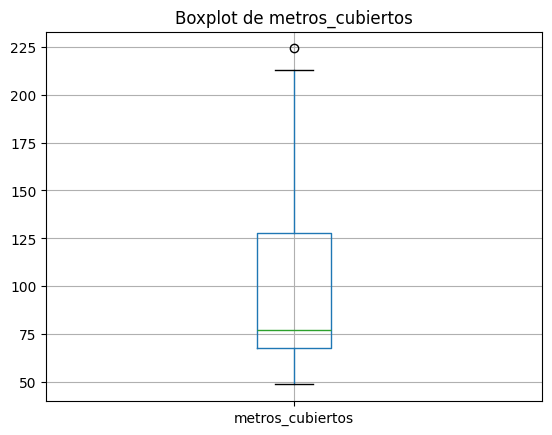

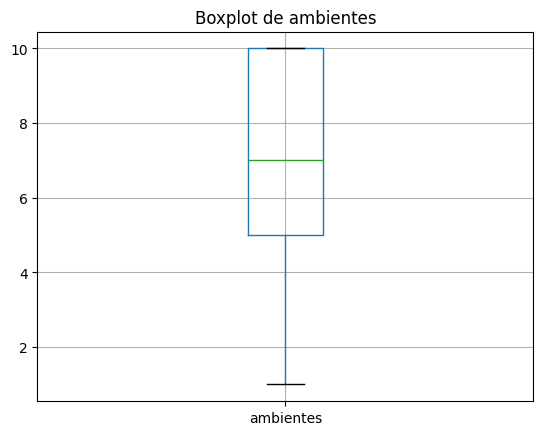

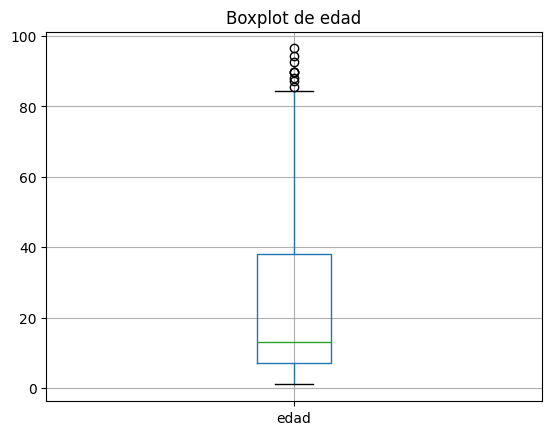

In [77]:
plt.figure()
plt.boxplot(dev.loc[dev['Ubicacion'] == 0, 'precio'].dropna())
plt.title('Boxplot Precio - Buenos Aires')
plt.show()

plt.figure()
plt.boxplot(dev.loc[dev['Ubicacion'] == 1, 'precio'].dropna())
plt.title('Boxplot Precio - Nueva York')
plt.show()
for col in dev.select_dtypes(include=['number']).columns:
	if col != 'precio' and col != 'Ubicacion' and col != 'pileta' and col != 'es_casa' and col != 'es_ph':
		plt.figure()
		dev.boxplot(column=col)
		plt.title(f'Boxplot de {col}')
		plt.show()

In [78]:
dev['pileta'].value_counts(normalize=True)*100

pileta
0   82.4375
1   17.5625
Name: proportion, dtype: float64

Un 82% de casas no tiene pileta pero hay un 18% que si. La feature puede aportar algo al modelo.

Analisis Boxplots (tomando en cuenta lo importante): 

- Precios: 
Buenos Aires: Concentrados entre 0 y 20000 con outliers arriba de 80000. Sesgo hacia valores altos.
Nueva York: Concentrados entre 100000 y 250000 con outliers arriba de 400000 y cercanos a 0.

- Area:
Concentrada entre 50 y 200 con outliers arriba de 250.

- Metros Cubiertos:
Concentrado entre 75 y 125 pero con outliers arriba de 200

- Ambientes:
Rango entre 1 y 10. Distribucion pareja.

- Edad:
Valores concentrados entre 0 y 40 años, otliers arriba de 80 años, generando sesgo hacia casas nuevas.



- Los outliers pueden distorsionar el modelo. 
- Los precios entre Buenos Aires y Nueva York estan en escalas muy distintas. Ademas, en cada uno hay valores muy cercanos a 0. Los que sean 0 seran detectados como error y los que no habria que analizar para detectar si pueden ser alquileres.
- La normalizacion lleva todas las variables a una misma escala, permitiendo que el algoritmo de gradiente descendiente converja de forma mas rapida y estable.


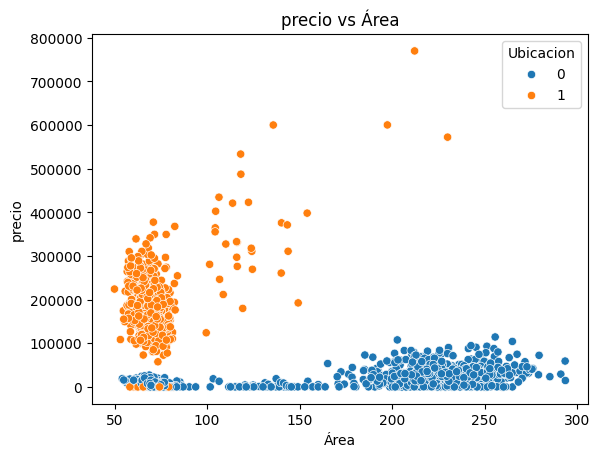

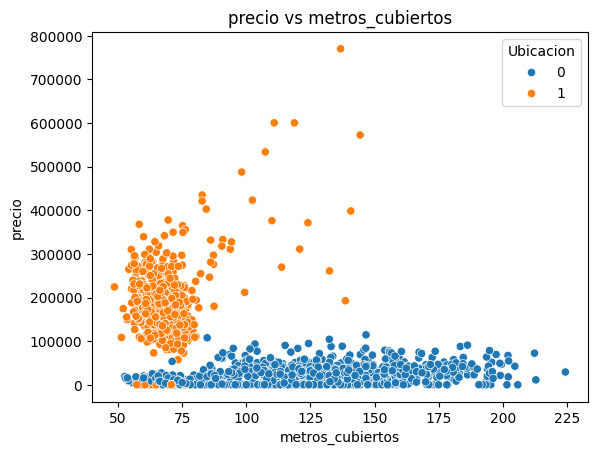

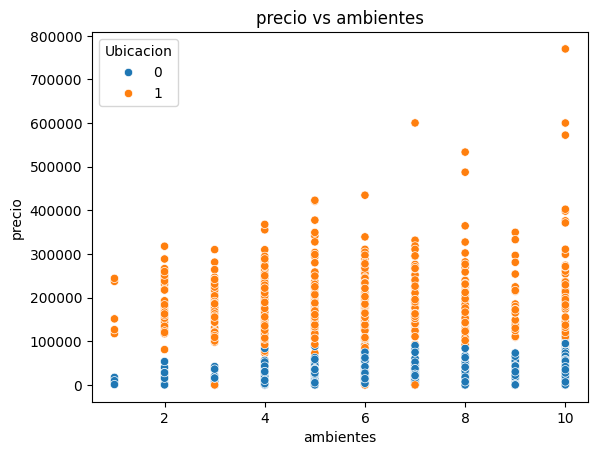

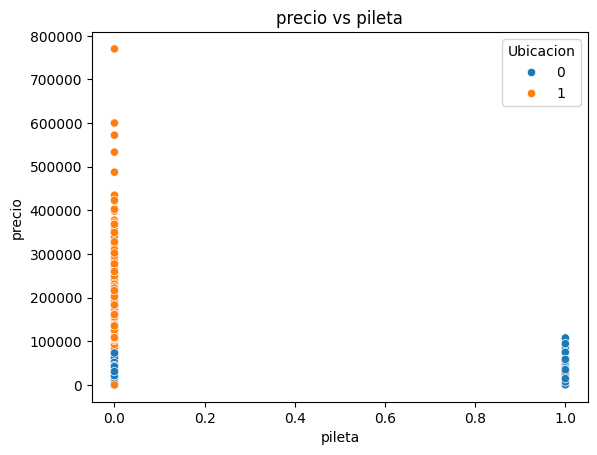

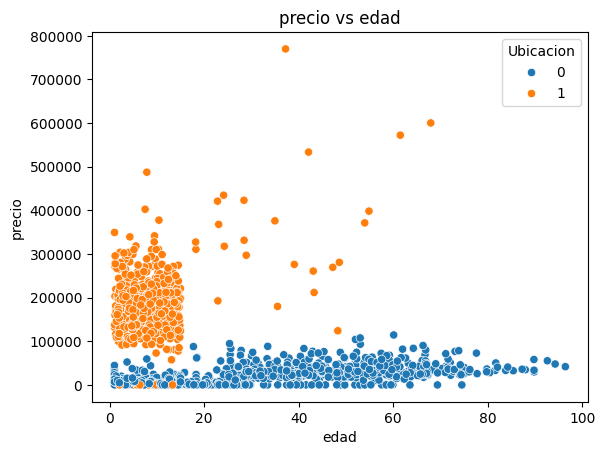

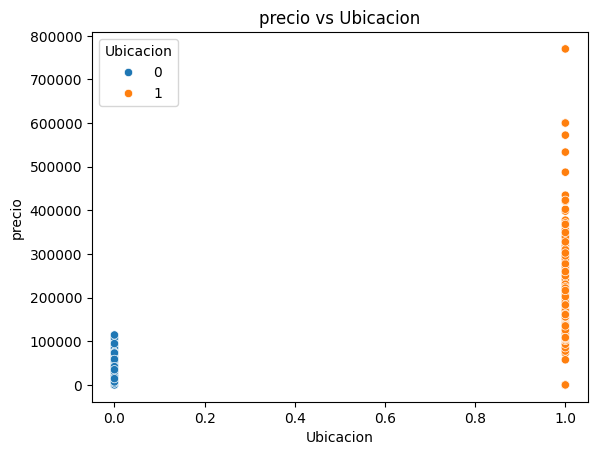

In [79]:
for col in dev.select_dtypes(include=['number']).columns:
    if col != 'precio' and col != 'es_casa' and col != 'es_ph':
        plt.figure()
        sns.scatterplot(data=dev, x=col, y='precio', hue='Ubicacion')
        plt.title(f'precio vs {col}')
        plt.show()

Relaciones importantes:
- Precio vs Area/Metro cubiertos:
Cuanto mas terreno/espacio --> mas alto el precio

- Precio vs Pileta:
En Buenos Aires aumenta el precio al tener pileta (por clima)

-Precio vs Ubicacion:
Claramente hay diferencias de escala por la moneda.


- Precio vs ambientes: 
Telación poco clara

- Precio vs edad: 
No depende tanto


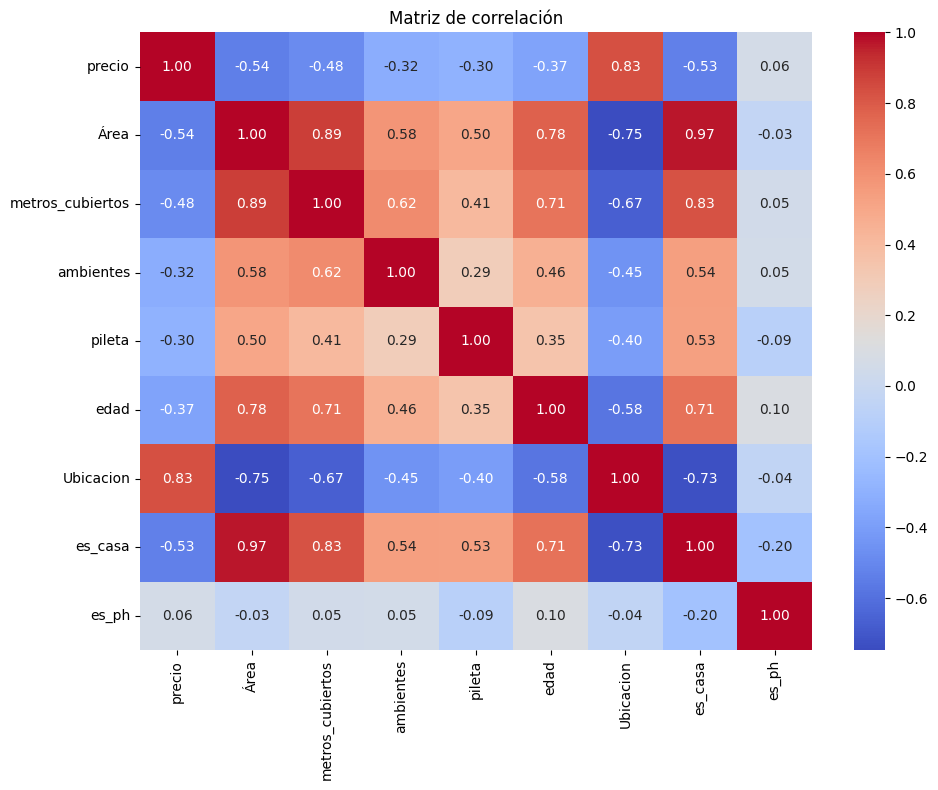

In [118]:
plt.figure(figsize=(10, 8))
sns.heatmap(dev.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

- La Ubicacion tiene la mayor correlacion con el precio, por lo que se afirma que es una feature importante.
- Area y metros_cubiertos tienen 0.89, lo que demuestra su multicolinealidad.
- En es_casa y ambientes (0.97) demuestra que las casas tienden a ser mas grandes (lo cual tiene sentido)
- Las correlaciones negativas con el precio y area se deben a la mezcla de paises (la diferencia extraña entre los precios de cada pais)

1.3

Separo dataset (80% train - 20% validation)

In [80]:
from src.data_splitting import train_val_split	

In [81]:
train_set,validation_set = train_val_split(dev)

Normalizacion de variables

Normalizo en memoria (no cambio csv) --> Quiero mantener dataset original

In [82]:
train_original = pd.read_csv("../data/casas_train.csv")
validation_original = pd.read_csv("../data/casas_validation.csv")

In [83]:
train = train_original.copy()
validation = validation_original.copy()

Reemplazo de NaNs

In [84]:
media_precios_NYC = (train.loc[train['Ubicacion'] == 1, 'precio']).mean()
media_precios_BUE = (train.loc[train['Ubicacion'] == 0, 'precio']).mean()
media_edad_NYC = (train.loc[train['Ubicacion'] == 1, 'edad']).mean()
media_edad_BUE = (train.loc[train['Ubicacion'] == 0, 'edad']).mean()

for parte in [train,validation]:
	parte.loc[(parte['precio'].isna()) & (parte['Ubicacion'] == 1), 'precio'] = media_precios_NYC
	parte.loc[(parte['precio'].isna()) & (parte['Ubicacion'] == 0), 'precio'] = media_precios_BUE
	parte.loc[(parte['edad'].isna()) & (parte['Ubicacion'] == 1), 'edad'] = media_edad_NYC
	parte.loc[(parte['edad'].isna()) & (parte['Ubicacion'] == 0), 'edad'] = media_edad_BUE

In [85]:
from src.preprocessing import normalizar,desnormalizar
train_normalizado, validation_normalizado, media_var = normalizar(['precio','Área','metros_cubiertos', 'ambientes','edad'],train,validation)

Visualizacion de variables normalizadas:

In [86]:
train_normalizado.sample(5)

,precio,Área,metros_cubiertos,ambientes,pileta,edad,Ubicacion,es_casa,es_ph
236,1.0958,-0.9014,-0.8621,-0.3575,0,-1.0325,1,0,0
504,-0.6849,1.4011,1.0978,0.4460,0,2.0826,0,1,0
1196,0.7452,-0.8502,-0.7261,0.0443,0,-0.8330,1,0,0
364,1.2165,-0.8357,-0.6694,-1.1611,0,-0.9866,1,0,0
1217,-0.9856,1.2530,1.0398,1.2496,1,-0.5386,0,1,0


In [87]:
validation_normalizado.sample(5)

,precio,Área,metros_cubiertos,ambientes,pileta,edad,Ubicacion,es_casa,es_ph
25,-0.9761,-0.8565,-0.7254,-2.3664,0,-0.9380,0,0,0
1,-0.9820,1.0022,0.8795,-0.7593,1,0.5245,0,1,0
310,-0.6846,1.4261,1.0935,1.2496,0,0.4067,0,1,0
302,-0.8312,-0.9420,-0.9436,0.0443,0,-0.9813,0,0,0
142,0.9553,-1.0351,-1.1106,-0.7593,0,-0.9988,1,0,0


In [88]:
pd.set_option('display.float_format', '{:.4f}'.format)
print("Antes de normalizar:")
print(pd.read_csv("../data/casas_train.csv").describe())
print("\nDespués de normalizar:")
print(train_normalizado.describe())

Antes de normalizar:
           precio      Área  metros_cubiertos  ambientes    pileta      edad  \
count   1239.0000 1280.0000         1280.0000  1280.0000 1280.0000 1163.0000   
mean   93090.7925  138.4422           98.0488     6.8898    0.1727   22.5859   
std    95032.7605   78.4428           38.2706     2.4890    0.3781   20.6883   
min        0.0000   49.9716           48.6101     1.0000    0.0000    1.0000   
25%    16214.7162   69.2493           67.4083     5.0000    0.0000    7.0987   
50%    43877.0661   79.1543           77.0064     7.0000    0.0000   13.0890   
75%   168730.1322  223.2534          126.9621    10.0000    0.0000   37.4431   
max   600370.8820  293.6375          224.3524    10.0000    1.0000   94.2724   

       Ubicacion   es_casa     es_ph  
count  1280.0000 1280.0000 1280.0000  
mean      0.4367    0.4109    0.0531  
std       0.4962    0.4922    0.2244  
min       0.0000    0.0000    0.0000  
25%       0.0000    0.0000    0.0000  
50%       0.0000    0.00

Todo se normalizo correctamente




EJERCICIO 2

In [89]:
nombres_features = train_normalizado.drop('precio',axis=1).columns

X_train_todas_vars = train_normalizado.drop('precio',axis=1).values

X_train_una_var = train_normalizado['Área'].values

y_train_norm = train_normalizado['precio'].values
y_validation_norm = validation_normalizado['precio'].values

Entrenamiento con Pseudo Inversa

Todas las variables

In [90]:
modelo_pi_todas = LinearRegression(X_train_todas_vars, y_train_norm,nombres_features)
modelo_pi_todas.entrenar_pseudo_inv()
modelo_pi_todas.coefs_con_features()
y_pred_pi_todas = modelo_pi_todas.X @ modelo_pi_todas.w
print("ECM:", ECM(y_train_norm, y_pred_pi_todas))

-1.1976
 -0.1639 x Área
 -0.0266 x metros_cubiertos
 0.0071 x ambientes
 0.0334 x pileta
 0.0751 x edad
 2.0093 x Ubicacion
 0.6642 x es_casa
 0.7783 x es_ph
ECM: 0.25753737719297914


Una variable

In [91]:
modelo_pi_1 = LinearRegression(X_train_una_var, y_train_norm,nombres_features)
modelo_pi_1.entrenar_pseudo_inv()
modelo_pi_1.coefs_con_features()
y_pred_pi_1 = modelo_pi_1.X @ modelo_pi_1.w
print("ECM:", ECM(y_train_norm, y_pred_pi_1))

0.0
 -0.5594 x Área
ECM: 0.6865139696898104


Entrenamiento con Gradiente Descendiente

In [92]:
alfa = 0.1
iteraciones = 1000

In [93]:
modelo_gd_todas = LinearRegression(X_train_todas_vars, y_train_norm,nombres_features)
modelo_gd_todas.entrenar_gradiente_descendiente(alfa,iteraciones)
modelo_gd_todas.coefs_con_features()
y_pred_gd_todas = modelo_gd_todas.X @ modelo_gd_todas.w
print("ECM:", ECM(y_train_norm, y_pred_gd_todas))

-1.0301
 0.0321 x Área
 -0.048 x metros_cubiertos
 0.0087 x ambientes
 0.0409 x pileta
 0.0693 x edad
 1.9971 x Ubicacion
 0.2874 x es_casa
 0.633 x es_ph
ECM: 0.25867744049275826


Una variable

In [94]:
modelo_gd_1 = LinearRegression(X_train_una_var, y_train_norm,nombres_features)
modelo_gd_1.entrenar_gradiente_descendiente(alfa,iteraciones)
modelo_gd_1.coefs_con_features()
y_pred_gd_1 = modelo_gd_1.X @ modelo_gd_1.w
print("ECM:", ECM(y_train_norm, y_pred_gd_1))

-0.0
 -0.5594 x Área
ECM: 0.6865139696898104


Implementacion correcta, modelos dan resultados similares

EJERCICIO 3

In [95]:
Modelo_1 = modelo_pi_1 #uso el mismo que use en el ej anterior
Modelo_1.coefs_con_features()
print("ECM:", ECM(y_train_norm, y_pred_pi_1))

0.0
 -0.5594 x Área
ECM: 0.6865139696898104


In [96]:
X_train_2 = train_normalizado[['Área','pileta']].values
Modelo_2 = LinearRegression(X_train_2, y_train_norm,train_normalizado[['Área', 'pileta']].columns)
Modelo_2.entrenar_pseudo_inv()
Modelo_2.coefs_con_features()
y_pred_M2 = Modelo_2.X @ Modelo_2.w
print("ECM:", ECM(y_train_norm, y_pred_M2))

0.0074
 -0.5511 x Área
 -0.0429 x pileta
ECM: 0.686319025391721


El valor del peso indica que la pileta casi que no afecta el precio de la propiedad (-0.0974). Esto en realidad es porque al no tener en cuenta la ubicacion y la distorsion en los precios con USA, que lo sesgan. En realidad el peso de la pileta deberia ser nulo o levemente positivo.

En el 3.3 sacaria es_ph (ya tengo es_casa) y pileta porque no aportan mucho

In [97]:
X_train_3 = train_normalizado[['Área','metros_cubiertos','edad','Ubicacion','es_casa','ambientes']].values
Modelo_3 = LinearRegression(X_train_3, y_train_norm,train[['Área','metros_cubiertos','edad','Ubicacion','es_casa','ambientes']].columns)
Modelo_3.entrenar_pseudo_inv()
y_pred_M3 = Modelo_3.X @ Modelo_3.w
Modelo_3.coefs_con_features()
print("ECM:", ECM(y_train_norm, y_pred_M3))

-0.7493
 0.2605 x Área
 -0.0392 x metros_cubiertos
 0.0848 x edad
 1.9612 x Ubicacion
 -0.261 x es_casa
 0.0125 x ambientes
ECM: 0.27434739722847856


Hay pesos que son extraños, por ejemplo peso de metros cubiertos negativo. Esto puede ser porque al ser una feature tan correlacionada con Area, produce inestabilidad (no es clara la contribucion de cada uno).

EJERCICIO 4

Las features a agregar son:
- metros_cubiertos / area --> Me dicen proporcion construida del terreno
- pileta x Ubicacion --> Vimos que el que haya pileta, influye mas si es en Bs.As. que en NYC. --> 1 si tiene pileta y es de NYC (1 x 1) y 0 caso contrario.
- metros_cubiertos / ambientes --> saber el tamaño promedio por ambiente --> si los ambientes son mas amplios la casa podria valer mas


In [98]:
from src.feature_engeneering import crear_features

In [99]:
crear_features (train)
crear_features(validation)
cols_M4_a_norm = ['precio','Área','metros_cubiertos','edad','ambientes',
           'metros_cubiertos / Área','ambientes x Ubicacion','metros_cubiertos / ambientes'] #no normalizo las columnas binarias 

train_normalizado_M4,validation_normalizado_M4,media_var_M4 = normalizar(cols_M4_a_norm,train,validation)

In [100]:
X_train_4 = train_normalizado_M4.drop(['precio','es_ph','pileta'],axis=1).values
y_train_norm = train_normalizado_M4['precio']
Modelo_4 = LinearRegression(X_train_4,y_train_norm,train_normalizado_M4.drop(['precio','es_ph','pileta'],axis=1).columns)
Modelo_4.entrenar_pseudo_inv()
y_pred_M4 = Modelo_4.X @ Modelo_4.w
print("ECM:",ECM(y_train_norm,y_pred_M4))
Modelo_4.coefs_con_features()


ECM: 0.2615338273751732
-0.6167
 -0.8293 x Área
 0.5821 x metros_cubiertos
 -0.0434 x ambientes
 0.0837 x edad
 1.7703 x Ubicacion
 -0.3807 x es_casa
 -0.7049 x metros_cubiertos / Área
 0.1312 x ambientes x Ubicacion
 -0.0002 x metros_cubiertos / ambientes


FEATURES POLINOMICAS

In [101]:
from src.feature_engeneering import crear_features_polinomicas

In [102]:
grado_max = 7 #uso 7 para generar las 50 variables (7 * 6 + 6 originales)
cols_base = train.drop(['precio','es_ph','pileta','Ubicacion','es_casa'], axis=1).columns #no voy a elevar las binarias porque no cambia nada
crear_features_polinomicas(train, cols_base, grado_max)
crear_features_polinomicas(validation, cols_base, grado_max)

cols_a_norm = train.drop(['es_ph','pileta','Ubicacion','es_casa'], axis=1).columns
train_normalizado_M5, validation_normalizado_M5,media_var_M5 = normalizar(cols_a_norm, train, validation)

In [103]:
X_train_5 = train_normalizado_M5.drop(['precio','es_ph','pileta'],axis=1).values #estoy usando las nuevas mas la de el modelo 3
y_train_norm = train_normalizado_M5['precio']
Modelo_5 = LinearRegression(X_train_5,y_train_norm,train_normalizado_M5.drop(['es_ph','pileta'],axis=1).columns)
Modelo_5.entrenar_pseudo_inv()
y_pred_M5 = Modelo_5.X @ Modelo_5.w
print("ECM:",ECM(y_train_norm,y_pred_M5))

ECM: 0.2365490350683504


In [104]:
X_validation_5 = validation_normalizado_M5.drop(['precio','es_ph','pileta'],axis=1).values
X_val = np.column_stack((np.ones(len(X_validation_5)), X_validation_5))
y_pred_M5_val = X_val @ Modelo_5.w
y_validation_norm = validation_normalizado_M5['precio'] 
print("ECM:",ECM(y_validation_norm,y_pred_M5_val))

ECM: 0.3196934976583572


Se puede ver que el error es muy parecido entre el train y el validation. Pero si el grado se aumenta se logra ver que el modelo overfittea. El error de train se mantiene bajo pero el validation incrementa.

In [105]:

prediccion_m5 = desnormalizar('precio',y_pred_M5_val[:10],media_var_M5)
valores_reales_m5 = desnormalizar('precio',y_validation_norm[:10].values,media_var_M5)

print("Precios estimados por modelo 5:")
print(prediccion_m5)
print("Precios reales:")
print(valores_reales_m5)

Precios estimados por modelo 5:
[ 32587.66081593  35227.41397794  23573.63929494  53474.6962187
  -3544.98693519  62176.18429422  22901.72064578  18537.33259259
 185411.82161394 179006.10438545]
Precios reales:
[ 29641.77633244    341.58851306      0.          39828.75903586
   9478.61168342    729.66514342  17018.96655028   8188.3217779
 240389.48662488 111471.63452741]


Con estos experimentos esperaba que a medida que se aumente la cantidad de features, mejor predeciria (que fue lo que sucedio). Igualmente como es de esperarse, si se continua agregando features (principalmente polinomicas), el modelo comenzaria a overfittear debido a que estaria apoyandose demasiado en el train set, teniendo mala performance en el validation.


Ejercicio 5

Ridge

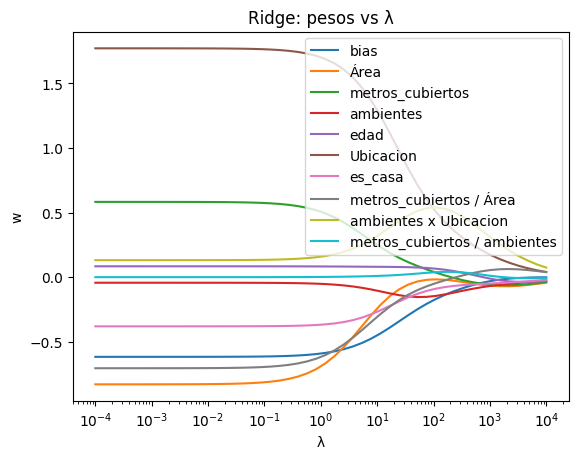

In [106]:
lambdas = np.logspace(-4, 4, 50)  # 50 valores de 0.0001 a 10000
pesos_por_lambda = []

for l2 in lambdas:
	modelo = LinearRegression(X_train_4,y_train_norm,train_normalizado_M4.drop(['precio','es_ph','pileta'],axis=1).columns,L1 = 0,L2 = l2)
	modelo.entrenar_pseudo_inv()
	pesos_por_lambda.append(modelo.w)

nombres_features_M4 = train_normalizado_M4.drop(['precio','es_ph','pileta'],axis=1).columns
nombres = ['bias'] + list(nombres_features_M4)
pesos_por_lambda = np.array(pesos_por_lambda) #convierto en matriz
for i in range(pesos_por_lambda.shape[1]):
		plt.plot(lambdas, pesos_por_lambda[:, i], label=nombres[i])
plt.legend()
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('w')
plt.title('Ridge: pesos vs λ')
plt.show()


- Se puede ver que a medida que lambda aumenta se toman los pesos mas cercanos al 0. Esto es porque el modelo busca minimizar el ECM. Si el lambda es chico, "gana" el ECM y los pesos quedan libres. Si lambda es grande, "gana" la penalizacion y quedan los pesos chicos. Es decir que el lambda controla el balance entre minimizar el error y mantener los pesos chicos.
- En este caso las "variables mas importantes", es decir las que ultimas se acercan al 0 son: la Ubicacion, el bias, el área, los metros cubiertos y luego las variables condicionadas. Se puede ver que la metros_cubiertos/ambiente es el que menos aporta.

LASSO

In [107]:
# lambdas = np.logspace(-4, 1, 50)  # 50 valores de 0.0001 a 10 (lo hago a 100 porque sino GD se vuelve muy inestable)
# pesos_por_lambda = []

# alfa = 0.0001
# iteraciones = 5000

# for l1 in lambdas:
# 	modelo = LinearRegression(X_train_4,y_train_norm,train_normalizado_M4.drop(['precio','es_ph','pileta'],axis=1).columns,L1 = l1,L2 = 0)
# 	modelo.entrenar_gradiente_descendiente(alfa,iteraciones) #no se puede entrenar pseudo inv. con LASSO
# 	pesos_por_lambda.append(modelo.w)

# pesos_por_lambda = np.array(pesos_por_lambda) #convierto en matriz
# for i in range(pesos_por_lambda.shape[1]):
#     plt.plot(lambdas, pesos_por_lambda[:, i], label=nombres[i])

# plt.legend()
# plt.xscale('log')
# plt.xlabel('λ')
# plt.ylabel('w')
# plt.title('LASSO: pesos vs λ')
# plt.show()

- La diferencia con Ridge es que a valores grandes de lambda, LASSO directamente elimina los pesos. Las ultimas variables que elimina son las que considera "mas importantes". Ademas, LASSO permite ver que features no estan aportando nada al modelo. 
- En este caso las "variables mas importantes", es decir las que ultimas llegan al 0 son: Ambientes x Ubicacion, la Ubicacion, el área y los metros cubiertos. Se puede ver que el bias y metros_cubiertos/ambientes son los que menos aportan.

L2 --> achica los pesos hacia cero pero nunca se vuelven exactamente 0

L1 -> achica los pesos hasta eliminarlos

CROSS VALIDATION

In [108]:
from src.data_splitting import cross_val

In [109]:
lambdas = np.logspace(-4, 2, 30)  # 50 valores de 0.0001 a 10 (lo hago a 100 porque sino GD se vuelve muy inestable)
ECMs_por_lambda = {"L1" : {}, "L2" : {}}

X_full = np.concatenate([X_train_4, validation_normalizado_M4.drop(['precio','es_ph','pileta'], axis=1).values]) #uso todo mi train (train y validation)
y_full = np.concatenate([y_train_norm, validation_normalizado_M4['precio'].values])

alfa = 0.0001
iteraciones = 5000
nombres_features_M6 = nombres_features_M4

k = 5
lambda_final = 0

for Li in ["L1", "L2"]:
	for l in lambdas:
		c_v_l = cross_val(X_full, y_full, k, l, Li, alfa, iteraciones, nombres_features_M6)
		ECMs_por_lambda[Li][l] = c_v_l

	ecm_values = np.array(list(ECMs_por_lambda[Li].values()))
	lambda_values = np.array(list(ECMs_por_lambda[Li].keys()))

	mejor_idx = np.argmin(ecm_values)
	mejor_lambda = lambda_values[mejor_idx]
	valor_mejor_lambda = ecm_values[mejor_idx]
	if mejor_lambda > lambda_final:
		lambda_final = mejor_lambda

	print(f'El mejor lambda para {Li} es {mejor_lambda} con ECM = {valor_mejor_lambda}')




El mejor lambda para L1 es 0.0002592943797404667 con ECM = 0.4476672907812011
El mejor lambda para L2 es 0.12689610031679222 con ECM = 0.27770728759459234


- En este caso Ridge Funciona mucho mejor que LASSO porque LASSO elimina features y con pocas features se puede perder informacion importante.
- Utilizaremos Ridge para el M6

In [110]:
Modelo_6 = LinearRegression(X_train_4, y_train_norm, nombres_features_M6, L2=lambda_final)
Modelo_6.entrenar_pseudo_inv()

array([-6.13218666e-01, -8.09176391e-01,  5.71153582e-01, -4.45003773e-02,
        8.35394131e-02,  1.76105355e+00, -3.79146822e-01, -6.92336718e-01,
        1.34764098e-01,  1.09366501e-05])

EJERCICIO 6

In [111]:
from src.utils import learning_curve

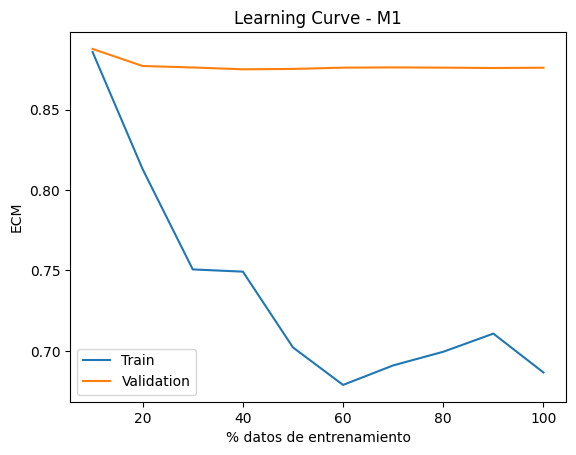

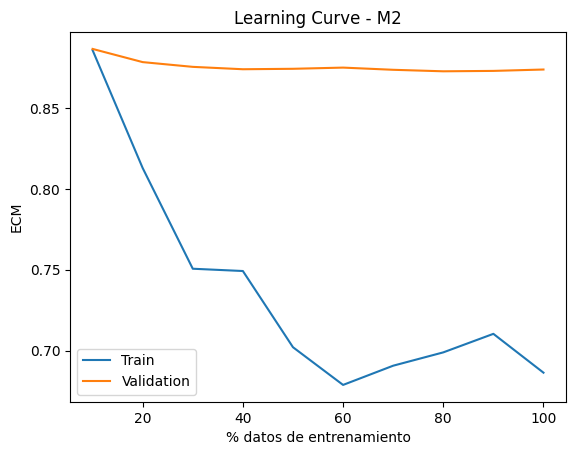

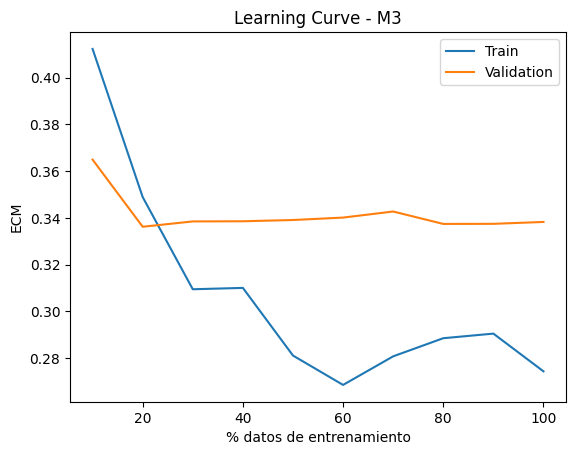

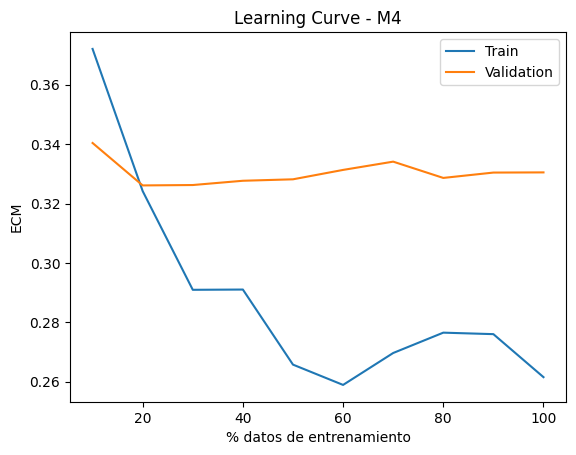

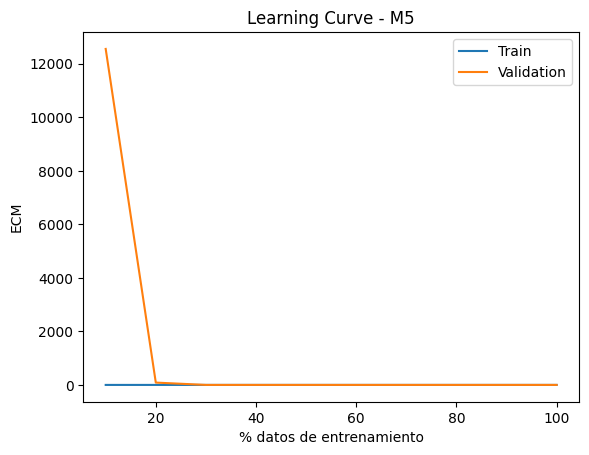

ECM train M5: 0.24818208849194412
ECM val M5: 0.32196435208181384


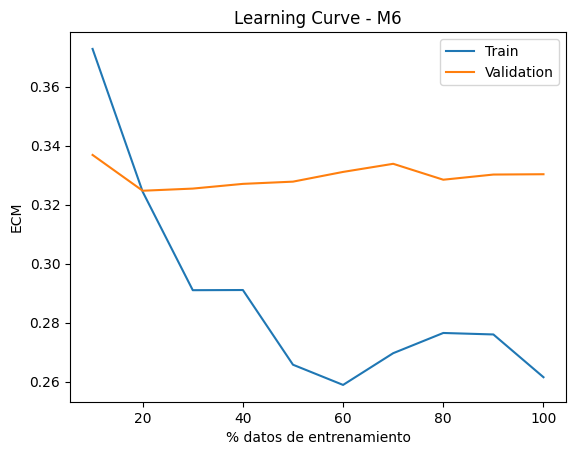

In [ ]:
#reordeno para tener todo junto
X_val_1 = validation_normalizado[['Área']].values
y_val = validation_normalizado['precio'].values

X_val_2 = validation_normalizado[['Área','pileta']].values

X_val_3 = validation_normalizado[['Área','metros_cubiertos','edad','Ubicacion','es_casa','ambientes']].values

X_val_4 = validation_normalizado_M4.drop(['precio','es_ph','pileta'], axis=1).values
y_val_M4 = validation_normalizado_M4['precio'].values

X_val_5 = validation_normalizado_M5.drop(['precio','es_ph','pileta'], axis=1).values
y_val_M5 = validation_normalizado_M5['precio'].values

l2 = lambda_final

info_modelos = [ ('M1', train_normalizado[['Área']].values, X_val_1, y_train_norm, y_val, ['Área'], 0),
    ('M2', train_normalizado[['Área','pileta']].values, X_val_2, y_train_norm, y_val, ['Área','pileta'], 0),
    ('M3', train_normalizado[['Área','metros_cubiertos','edad','Ubicacion','es_casa','ambientes']].values, X_val_3, y_train_norm, y_val, ['Área','metros_cubiertos','edad','Ubicacion','es_casa','ambientes'], 0),
    ('M4', X_train_4, X_val_4, train_normalizado_M4['precio'].values, y_val_M4, list(nombres_features_M4), 0),
    ('M5', X_train_5, X_val_5, train_normalizado_M5['precio'].values, y_val_M5, [], 0),
    ('M6', X_train_4, X_val_4, train_normalizado_M4['precio'].values, y_val_M4, list(nombres_features_M4), l2)]

porcentajes = np.arange(0.1, 1.1, 0.1)

for nombre, X_train, X_val, y_train, y_val, noms_columnas, l2 in info_modelos:
    ecm_train_list = []
    ecm_val_list = []
    
    for p in porcentajes:
        n = int(len(y_train) * p)
        X_subconjunto = X_train[:n]
        y_subconjunto = y_train[:n]
        
        modelo = LinearRegression(X_subconjunto, y_subconjunto, noms_columnas, L2=l2)
        modelo.entrenar_pseudo_inv()
        
        y_pred_train = modelo.X @ modelo.w
        ecm_train_list.append(ECM(y_subconjunto, y_pred_train))
        
        X_val_bias = np.column_stack((np.ones(len(X_val)), X_val))
        y_pred_val = X_val_bias @ modelo.w
        ecm_val_list.append(ECM(y_val, y_pred_val))
    
    plt.figure()
    plt.plot(porcentajes * 100, ecm_train_list, label='Train')
    plt.plot(porcentajes * 100, ecm_val_list, label='Validation')
    plt.xlabel('% datos de entrenamiento')
    plt.ylabel('ECM')
    plt.title(f'Learning Curve - {nombre}')
    plt.legend()
    plt.show()
    if nombre == "M5":
        print("ECM train M5:", ecm_train_list[-2])
        print("ECM val M5:", ecm_val_list[-2])


- M1 y M2 --> Underfitting normal por modelo muy simple (generaliza demasiado)
- M3 --> Train baja a 0.28 y validation a 0.34, viendo una mejora respecto a los modelos anteriores. Esto es claramente por agregar features importantes para el modelo.
- M4 --> Parecido al anterior pero mas estable desde el principio
- M5 --> Overfitting clarisimo. El gap del principio demuestra que con pocas muestras y muchos features el modelo memoriza y no generaliza nada. Cuando aumentan muchos los datos, el modelo se terimina forzando a aprender los patrones reales.
-M6 --> No se ve tanta diferencia en el grafico en comparacion con M4. Igualmente con la regularizacion que controla los pesos, lo hace mas estable hacia datos nuevos. Es por esta razon que para produccion optaria por utilizar este modelo.